# Indonesia E-Commerce Sales Analysis 2023–2025
**Platform:** Shopee Indonesia | **Tools:** Python (Pandas, Matplotlib, Seaborn) + Tableau

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress non-critical warnings untuk output yang lebih bersih
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Data

In [2]:
# Cell 2 — Load Data
df = pd.read_csv(r'all_months_clean.csv', sep=';', encoding='utf-8-sig')

# Copy data set to df_clean
df_clean = df.copy()

print(f"Data Loaded")
print(f"df asli : {df.shape[0]:,} baris, {df.shape[1]} kolom")
print(f"df_clean : {df_clean.shape[0]:,} baris, {df_clean.shape[1]} kolom")

Data Loaded
df asli : 20,848 baris, 19 kolom
df_clean : 20,848 baris, 19 kolom


## 3. Data Cleaning

### 3.1 Fix Tipe Data — Datetime

In [3]:
# Parse kolom waktu dari string ke datetime
# errors='coerce' — nilai yang tidak valid diubah ke NaT, bukan error
df_clean['Waktu Pesanan Dibuat'] = pd.to_datetime(
    df_clean['Waktu Pesanan Dibuat'], errors='coerce')

print(f"Tipe data : {df_clean['Waktu Pesanan Dibuat'].dtype}")
print(f"NaT count : {df_clean['Waktu Pesanan Dibuat'].isnull().sum():,}")

Tipe data : datetime64[ns]
NaT count : 1,980


### 3.2 Fix Tipe Data — Category

In [4]:
# Kolom dengan nilai unik terbatas diubah ke category
# untuk efisiensi memori dan performa analisis
kategorikal = ['Status Pesanan', 'Metode Pembayaran', 'Provinsi',
               'product_categories', 'Opsi Pengiriman', 'Kota/Kabupaten']

for col in kategorikal:
    df_clean[col] = df_clean[col].astype('category')

print("✅ Tipe category selesai")

✅ Tipe category selesai


### 3.3 Handle Anomali — Total Pembayaran = 0
> Order dengan status Selesai tetapi nilai pembayaran 0 (0.35% dari total) 
> diidentifikasi sebagai data error dan dihapus.

In [5]:
# Drop baris anomali: order Selesai dengan nilai pembayaran Rp 0
# Jumlah: ~56 baris (0.35% dari total) — aman untuk dihapus
sebelum = df_clean.shape[0]

df_clean = df_clean[~((df_clean['Total Pembayaran'] == 0) &
                       (df_clean['Status Pesanan'] == 'Selesai'))].copy()

sesudah = df_clean.shape[0]

print(f"Sebelum : {sebelum:,}")
print(f"Sesudah : {sesudah:,}")
print(f"Terhapus: {sebelum - sesudah:,}")

Sebelum : 20,848
Sesudah : 20,786
Terhapus: 62


### 3.4 Feature Engineering — Boolean Flag

In [6]:
# Boolean flag untuk mempercepat filtering di analisis selanjutnya
df_clean['is_selesai'] = df_clean['Status Pesanan'] == 'Selesai'
df_clean['is_batal']   = df_clean['Status Pesanan'] == 'Batal'

print(f"is_selesai : {df_clean['is_selesai'].sum():,}")
print(f"is_batal   : {df_clean['is_batal'].sum():,}")

is_selesai : 17,706
is_batal   : 2,830


### 3.5 Perbaiki Data Hilang — December 2024 & July 2025
> Dua file tanpa timestamp diperbaiki dengan tanggal representatif (hari ke-15)
> karena analisis dilakukan pada level bulanan.

In [8]:
# Load dua file yang tidak memiliki kolom Waktu Pesanan Dibuat
dec = pd.read_excel(r'DecemberSales2024_clean.xlsx')
jul = pd.read_excel(r'JulySales2025_clean.xlsx')

# Isi waktu dengan tanggal representatif (hari ke-15)
# Alasan: analisis dilakukan pada level bulanan, bukan harian
dec['Waktu Pesanan Dibuat'] = '2024-12-15'
dec['source_file']          = 'DecemberSales2024.xlsx'

jul['Waktu Pesanan Dibuat'] = '2025-07-15'
jul['source_file']          = 'JulySales2025.xlsx'

# Samakan tipe data dengan df_clean sebelum digabungkan
for _df in [dec, jul]:
    _df['Waktu Pesanan Dibuat'] = pd.to_datetime(_df['Waktu Pesanan Dibuat'])
    _df['is_selesai'] = _df['Status Pesanan'] == 'Selesai'
    _df['is_batal']   = _df['Status Pesanan'] == 'Batal'
    for col in kategorikal:
        _df[col] = _df[col].astype('category')

print(f"dec : {dec.shape} | jul : {jul.shape}")

dec : (1214, 21) | jul : (766, 21)


### 3.6 Gabungkan Semua Data

In [9]:
# Gabungkan dataset utama dengan dua file yang diperbaiki
# ignore_index=True — reset index agar tidak ada duplikat
df_clean = pd.concat([df_clean, dec, jul], ignore_index=True).copy()

print(f"✅ df_clean final : {df_clean.shape[0]:,} baris, {df_clean.shape[1]} kolom")
print(f"is_selesai ada   : {'is_selesai' in df_clean.columns}")

✅ df_clean final : 22,766 baris, 21 kolom
is_selesai ada   : True


### 3.7 Buat df_time — Untuk Analisis Tren
> df_time hanya berisi baris yang memiliki data waktu valid.
> Digunakan khusus untuk analisis tren bulanan/tahunan.

In [10]:
# df_time — subset df_clean yang memiliki data waktu valid
# Digunakan khusus untuk analisis tren bulanan & tahunan
df_time = df_clean.dropna(subset=['Waktu Pesanan Dibuat']).copy()

# Ekstrak komponen waktu untuk kemudahan analisis
df_time['Tahun']      = df_time['Waktu Pesanan Dibuat'].dt.year.astype(int)
df_time['Bulan']      = df_time['Waktu Pesanan Dibuat'].dt.month.astype(int)
df_time['Nama_Bulan'] = df_time['Waktu Pesanan Dibuat'].dt.strftime('%b %Y')
df_time['Hari']       = df_time['Waktu Pesanan Dibuat'].dt.day_name()

# BulanDT: semua tanggal dibulatkan ke awal bulan
# untuk pengelompokan tren bulanan di visualisasi
df_time['BulanDT'] = df_time['Waktu Pesanan Dibuat'].dt.to_period('M').dt.to_timestamp()

print(f"✅ df_time  : {df_time.shape[0]:,} baris")
print(f"is_selesai ada : {'is_selesai' in df_time.columns}")

✅ df_time  : 20,792 baris
is_selesai ada : True


## 4. Exploratory Data Analysis (EDA)

### 4.1 Tren Revenue Bulanan

In [12]:
# Agregasi revenue dan jumlah order per bulan
# Hanya order Selesai yang dihitung sebagai revenue
monthly_revenue = df_time[df_time['is_selesai']].groupby(
    'BulanDT'
).agg(
    Total_Revenue = ('Total Pembayaran', 'sum'),
    Total_Order   = ('order_id', 'count')
).reset_index()

print(monthly_revenue)

      BulanDT  Total_Revenue  Total_Order
0  2023-12-01       23850125          352
1  2024-01-01       24492481          367
2  2024-02-01       21141376          327
3  2024-03-01       30259734          389
4  2024-04-01       21260662          402
5  2024-05-01       35530574          524
6  2024-06-01       32465925          608
7  2024-07-01       63791545         1110
8  2024-08-01       65939126         1094
9  2024-09-01       71193097          962
10 2024-10-01       68444255         1056
11 2024-11-01       54907940          889
12 2024-12-01       56060258         1047
13 2025-01-01       53240632          999
14 2025-02-01       53088026          831
15 2025-03-01       43689770          513
16 2025-04-01       35077659          677
17 2025-05-01       29139406          645
18 2025-06-01       30576496          519
19 2025-07-01       41642561          676
20 2025-08-01       46950416          852
21 2025-09-01       47056602         1013
22 2025-10-01       61464654      

### 4.2 Visualisasi Tren Revenue Bulanan

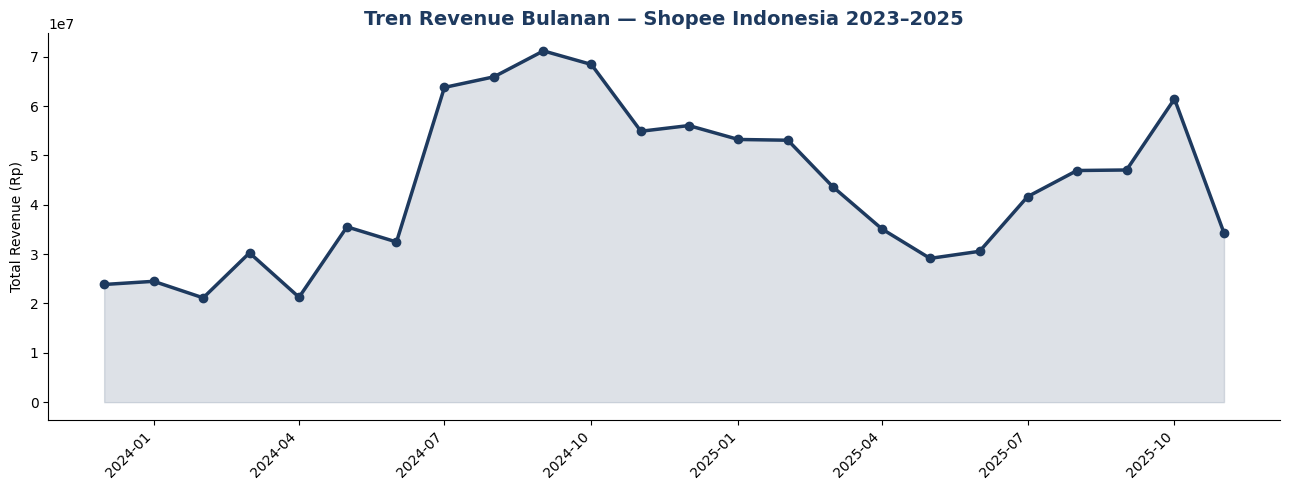

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

# Area di bawah garis — efek visual shadow
ax.fill_between(monthly_revenue['BulanDT'],
                monthly_revenue['Total_Revenue'],
                alpha=0.15, color='#1E3A5F')

# Garis utama dengan marker di tiap titik data
ax.plot(monthly_revenue['BulanDT'],
        monthly_revenue['Total_Revenue'],
        color='#1E3A5F', lw=2.5, marker='o', ms=6)

# Label & styling
ax.set_title('Tren Revenue Bulanan — Shopee Indonesia 2023–2025',
             fontsize=14, fontweight='bold', color='#1E3A5F')
ax.set_ylabel('Total Revenue (Rp)')
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Perbandingan Revenue 2024 vs 2025

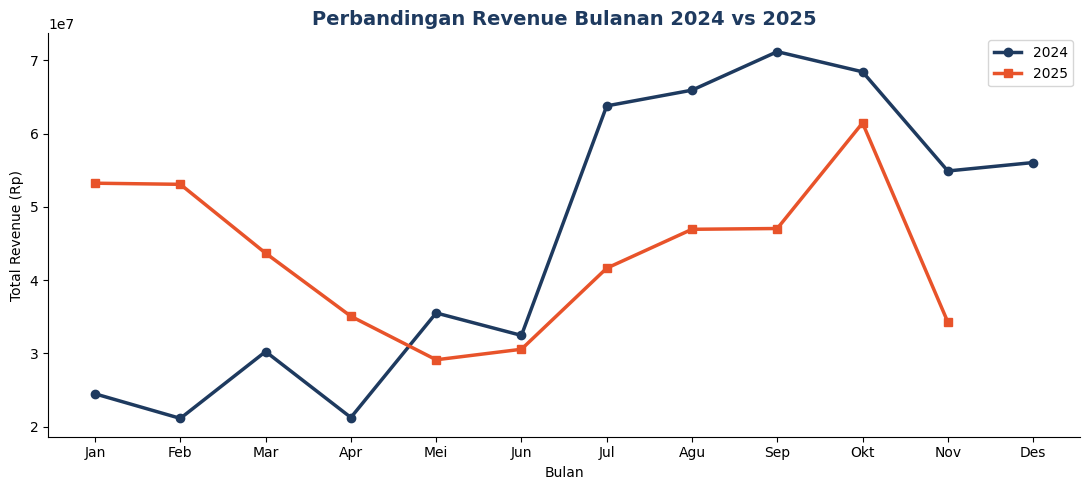

Avg Revenue 2024 : Rp 45,457,248
Avg Revenue 2025 : Rp 43,292,149
Growth           : -4.8%


In [14]:
# Filter hanya 2024 dan 2025 (exclude Des 2023 yang hanya 1 bulan)
monthly_2024 = monthly_revenue[monthly_revenue['BulanDT'].dt.year == 2024]
monthly_2025 = monthly_revenue[monthly_revenue['BulanDT'].dt.year == 2025]

fig, ax = plt.subplots(figsize=(11, 5))

# Plot dua tahun dengan warna berbeda
ax.plot(monthly_2024['BulanDT'].dt.month,
        monthly_2024['Total_Revenue'],
        color='#1E3A5F', lw=2.5, marker='o', ms=6, label='2024')

ax.plot(monthly_2025['BulanDT'].dt.month,
        monthly_2025['Total_Revenue'],
        color='#E8532A', lw=2.5, marker='s', ms=6, label='2025')

ax.set_title('Perbandingan Revenue Bulanan 2024 vs 2025',
             fontsize=14, fontweight='bold', color='#1E3A5F')
ax.set_ylabel('Total Revenue (Rp)')
ax.set_xlabel('Bulan')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun',
                    'Jul','Agu','Sep','Okt','Nov','Des'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

# Summary statistik
print(f"Avg Revenue 2024 : Rp {monthly_2024['Total_Revenue'].mean():,.0f}")
print(f"Avg Revenue 2025 : Rp {monthly_2025['Total_Revenue'].mean():,.0f}")
print(f"Growth           : {((monthly_2025['Total_Revenue'].mean() / monthly_2024['Total_Revenue'].mean()) - 1) * 100:+.1f}%")

### 4.4 Analisis Cancel Rate Bulanan

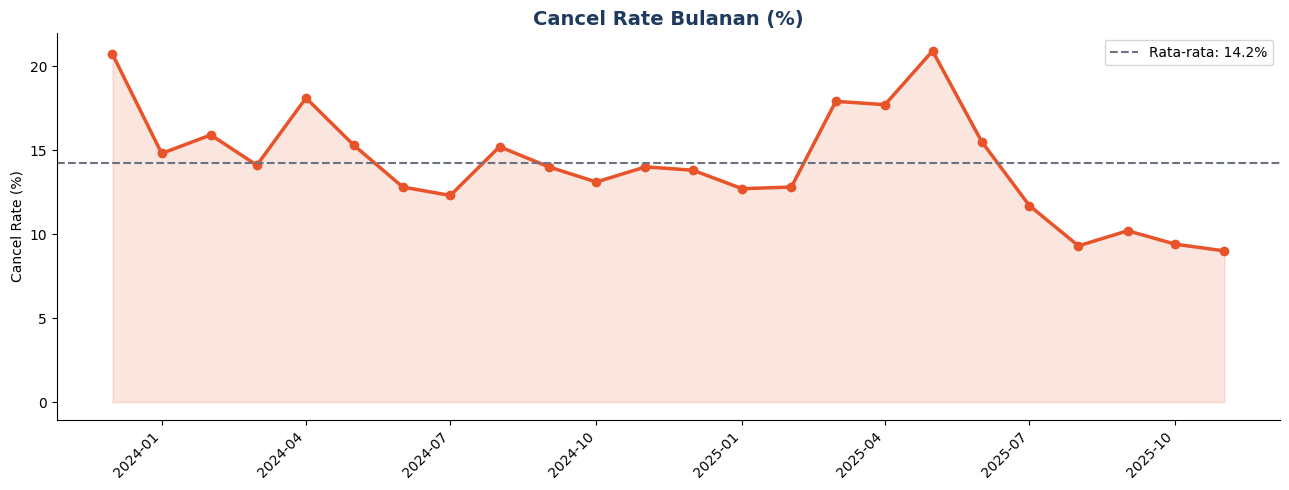

Rata-rata Cancel Rate : 14.2%
Tertinggi : 20.9% (May 2025)
Terendah  : 9.0% (Nov 2025)


In [15]:
# Hitung cancel rate per bulan
cancel_monthly = df_time.groupby('BulanDT').agg(
    Total_Order  = ('order_id', 'count'),
    Total_Batal  = ('is_batal', 'sum')
).reset_index()

# Cancel rate = order batal / total order per bulan
cancel_monthly['Cancel_Rate_%'] = (
    cancel_monthly['Total_Batal'] /
    cancel_monthly['Total_Order'] * 100
).round(1)

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(cancel_monthly['BulanDT'],
                cancel_monthly['Cancel_Rate_%'],
                alpha=0.15, color='#E8532A')
ax.plot(cancel_monthly['BulanDT'],
        cancel_monthly['Cancel_Rate_%'],
        color='#E8532A', lw=2.5, marker='o', ms=6)

# Garis rata-rata sebagai referensi
avg_cancel = cancel_monthly['Cancel_Rate_%'].mean()
ax.axhline(avg_cancel, color='#6B7280', ls='--', lw=1.5,
           label=f'Rata-rata: {avg_cancel:.1f}%')

ax.set_title('Cancel Rate Bulanan (%)',
             fontsize=14, fontweight='bold', color='#1E3A5F')
ax.set_ylabel('Cancel Rate (%)')
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Rata-rata Cancel Rate : {avg_cancel:.1f}%")
print(f"Tertinggi : {cancel_monthly['Cancel_Rate_%'].max():.1f}% "
      f"({cancel_monthly.loc[cancel_monthly['Cancel_Rate_%'].idxmax(), 'BulanDT'].strftime('%b %Y')})")
print(f"Terendah  : {cancel_monthly['Cancel_Rate_%'].min():.1f}% "
      f"({cancel_monthly.loc[cancel_monthly['Cancel_Rate_%'].idxmin(), 'BulanDT'].strftime('%b %Y')})")

### 4.5 Analisis Kategori Produk

In [18]:
# Agregasi revenue dan order per kategori — hanya order Selesai
kategori_stats = df_clean[df_clean['is_selesai']].groupby(
    'product_categories', observed=True
).agg(
    Total_Order   = ('order_id', 'count'),
    Total_Revenue = ('Total Pembayaran', 'sum'),
    Avg_Revenue   = ('Total Pembayaran', 'mean')
).sort_values('Total_Revenue', ascending=False).head(10)

print(kategori_stats)

                        Total_Order  Total_Revenue    Avg_Revenue
product_categories                                               
Seal / Baut / Roof              635      304600963  479686.555906
Celengan                       5238      161674316   30865.657885
Mangkok Sambal / Saus          3427      137900525   40239.429530
Nampan / Tray                  1264      107971527   85420.511867
Lunch Box / Rantang             443       50214804  113351.702032
Other                           407       40955582  100627.965602
Aksesoris Pintu                2759       40202575   14571.429866
Baskom / Mangkok Besar          502       35431950   70581.573705
Rak / Rak Serbaguna             421       32852840   78035.249406
Keranjang                       442       14991028   33916.352941


### 4.6 Analisis Geografis — Top Provinsi

In [19]:
# Revenue per provinsi — identifikasi konsentrasi pasar
provinsi_stats = df_clean[df_clean['is_selesai']].groupby(
    'Provinsi', observed=True
).agg(
    Total_Order   = ('order_id', 'count'),
    Total_Revenue = ('Total Pembayaran', 'sum')
).sort_values('Total_Revenue', ascending=False).head(10)

# Hitung market share per provinsi
provinsi_stats['Market_Share_%'] = (
    provinsi_stats['Total_Revenue'] /
    provinsi_stats['Total_Revenue'].sum() * 100
).round(1)

print(provinsi_stats)

                  Total_Order  Total_Revenue  Market_Share_%
Provinsi                                                    
JAWA BARAT               6355      306209262            31.0
BANTEN                   3450      191201990            19.4
DKI JAKARTA              2726      143898557            14.6
JAWA TENGAH              1451      110051543            11.2
JAWA TIMUR               1474      103014893            10.4
SUMATERA SELATAN          579       43937950             4.5
BALI                      176       24326072             2.5
LAMPUNG                   452       23094502             2.3
SULAWESI SELATAN          224       21237472             2.2
SUMATERA UTARA            260       19593051             2.0


### 4.7 Analisis Metode Pembayaran

In [20]:
# Distribusi metode pembayaran — identifikasi risiko COD
payment_stats = df_clean[df_clean['is_selesai']].groupby(
    'Metode Pembayaran', observed=True
).agg(
    Total_Order   = ('order_id', 'count'),
    Total_Revenue = ('Total Pembayaran', 'sum')
).sort_values('Total_Order', ascending=False)

# Persentase order per metode pembayaran
payment_stats['Order_%'] = (
    payment_stats['Total_Order'] /
    payment_stats['Total_Order'].sum() * 100
).round(1)

print(payment_stats)

                           Total_Order  Total_Revenue  Order_%
Metode Pembayaran                                             
COD (Bayar di Tempat)            10742      444941944     55.3
Saldo ShopeePay                   3679      263120480     18.9
Online Payment                    2804      266143219     14.4
SPayLater                         1356      100631466      7.0
SeaBank Bayar Instan               589       37751621      3.0
Kartu Kredit/Debit                 207       20173442      1.1
Indomaret/i.Saku                    23        4367947      0.1
Alfamart/Alfamidi/Dan+Dan           20        5218230      0.1
Pembayaran dibebaskan                4              0      0.0
Cicilan Kartu Kredit                 3         789704      0.0
BCA OneKlik                          2         115500      0.0


## 5. Export Data untuk Tableau

In [17]:
# Export df_clean — untuk analisis produk, pembayaran, provinsi
df_clean.to_csv('ecommerce_clean.csv', index=False, encoding='utf-8-sig')

# Export df_time — untuk analisis tren bulanan
df_time.to_csv('ecommerce_time.csv', index=False, encoding='utf-8-sig')

print(f"✅ ecommerce_clean.csv : {df_clean.shape[0]:,} baris")
print(f"✅ ecommerce_time.csv  : {df_time.shape[0]:,} baris")

✅ ecommerce_clean.csv : 22,766 baris
✅ ecommerce_time.csv  : 20,792 baris


## 6. Key Insights & Rekomendasi Bisnis

In [22]:
insights = {
    "📍 Geografis": [
        "65% revenue terkonsentrasi di 3 provinsi Jawa",
        "Rekomendasi: ekspansi ke Sumatera & Kalimantan untuk buka 35% potensi revenue baru"
    ],
    "💳 Pembayaran": [
        "COD mendominasi 55% transaksi — risiko gagal bayar tinggi",
        "Rekomendasi: filter COD untuk pelanggan loyal, diskon untuk pembayaran online"
    ],
    "📈 Momen Sale": [
        "Revenue tertinggi September 2024 (Rp 71.193.097) — bertepatan 9.9 Shopee Sale",
        "Rekomendasi: maksimalkan budget iklan & stok di periode 9.9, 10.10, dan 12.12"
    ],
    "❌ Cancel Rate": [
        "Cancel rate 13.6% — di atas rata-rata industri 8-10%",
        "Tertinggi Juni 2025 — korelasi dengan implementasi pajak e-commerce 0.5%",
        "Rekomendasi: perbaiki UI checkout dan tambah notifikasi reminder pembayaran"
    ],
    "🏆 Produk": [
        "Seal/Baut/Roof = revenue driver (Rp 245jt), Celengan = traffic driver (6.366 orders)",
        "Rekomendasi: pertahankan stok Seal/Baut/Roof, gunakan Celengan sebagai produk entry"
    ]
}

print("=" * 60)
print("   💡 KEY INSIGHTS — Indonesia E-Commerce 2023–2025")
print("=" * 60)
for category, points in insights.items():
    print(f"\n{category}")
    for p in points:
        print(f"   • {p}")
print("\n" + "=" * 60)

   💡 KEY INSIGHTS — Indonesia E-Commerce 2023–2025

📍 Geografis
   • 65% revenue terkonsentrasi di 3 provinsi Jawa
   • Rekomendasi: ekspansi ke Sumatera & Kalimantan untuk buka 35% potensi revenue baru

💳 Pembayaran
   • COD mendominasi 55% transaksi — risiko gagal bayar tinggi
   • Rekomendasi: filter COD untuk pelanggan loyal, diskon untuk pembayaran online

📈 Momen Sale
   • Revenue tertinggi September 2024 (Rp 71.193.097) — bertepatan 9.9 Shopee Sale
   • Rekomendasi: maksimalkan budget iklan & stok di periode 9.9, 10.10, dan 12.12

❌ Cancel Rate
   • Cancel rate 13.6% — di atas rata-rata industri 8-10%
   • Tertinggi Juni 2025 — korelasi dengan implementasi pajak e-commerce 0.5%
   • Rekomendasi: perbaiki UI checkout dan tambah notifikasi reminder pembayaran

🏆 Produk
   • Seal/Baut/Roof = revenue driver (Rp 245jt), Celengan = traffic driver (6.366 orders)
   • Rekomendasi: pertahankan stok Seal/Baut/Roof, gunakan Celengan sebagai produk entry

